In [28]:
import pandas as pd
import numpy as np

## Time benchmarks

In [29]:
# open the npy file
time_fl = np.load('benchmarks_fl.npy', allow_pickle=True).item()

In [30]:

for k, v in time_fl.items():
    print(k, ":", np.round(np.mean(v), 4), np.round(np.std(v), 4))

fl_25_cuda_tomopy_fbp_stride-1 : 4.2567 0.1436
fl_25_cuda_tomopy_sart_stride-100 : 1.8816 0.0007
fl_25_tomopy_fbp_cpu_stride-100_core-1 : 0.23 0.0007
fl_25_tomopy_fbp_cpu_stride-1_core-8 : 2.888 0.0297
fl_50_cuda_tomopy_fbp_stride-1 : 4.6677 0.0033
fl_50_cuda_tomopy_sart_stride-100 : 1.9323 0.005
fl_50_tomopy_fbp_cpu_stride-100_core-1 : 0.4569 0.0008
fl_50_tomopy_fbp_cpu_stride-1_core-8 : 5.8885 0.1368
fl_400_cuda_tomopy_fbp_stride-1 : 13.1696 0.0412
fl_400_cuda_tomopy_sart_stride-100 : 2.0166 0.0037


In [48]:
time_cuda_sart = {
    '1x': (
        100 * np.round(np.mean(time_fl['fl_400_cuda_tomopy_sart_stride-100']), 4),
        100 * np.round(np.std(time_fl['fl_400_cuda_tomopy_sart_stride-100']), 4)
    ),
    '8x': (
        100 * np.round(np.mean(time_fl['fl_50_cuda_tomopy_sart_stride-100']), 4),
        100 * np.round(np.std(time_fl['fl_50_cuda_tomopy_sart_stride-100']), 4)
    ),
    '16x': (
        100 * np.round(np.mean(time_fl['fl_25_cuda_tomopy_sart_stride-100']), 4),
        100 * np.round(np.std(time_fl['fl_25_cuda_tomopy_sart_stride-100']), 4)
    ),
}
time_cuda_fbp = {
    '1x': (
        np.round(np.mean(time_fl['fl_400_cuda_tomopy_fbp_stride-1']), 4),
        np.round(np.std(time_fl['fl_400_cuda_tomopy_fbp_stride-1']), 4)
    ),
    '8x': (
        np.round(np.mean(time_fl['fl_50_cuda_tomopy_fbp_stride-1']), 4),
        np.round(np.std(time_fl['fl_50_cuda_tomopy_fbp_stride-1']), 4)
    ),
    '16x': (
        np.round(np.mean(time_fl['fl_25_cuda_tomopy_fbp_stride-1']), 4),
        np.round(np.std(time_fl['fl_25_cuda_tomopy_fbp_stride-1']), 4)
    ),
}
time_1cpu_fbp = {
    '8x': (
        100 * np.round(np.mean(time_fl['fl_50_tomopy_fbp_cpu_stride-100_core-1']), 4),
        100 * np.round(np.std(time_fl['fl_50_tomopy_fbp_cpu_stride-100_core-1']), 4)
    ),
    '16x': (
        100 * np.round(np.mean(time_fl['fl_25_tomopy_fbp_cpu_stride-100_core-1']), 4),
        100 * np.round(np.std(time_fl['fl_25_tomopy_fbp_cpu_stride-100_core-1']), 4)
    ),
}
time_8cpu_fbp = {
    '8x': (
        np.round(np.mean(time_fl['fl_50_tomopy_fbp_cpu_stride-1_core-8']), 4),
        np.round(np.std(time_fl['fl_50_tomopy_fbp_cpu_stride-1_core-8']), 4)
    ),
    '16x': (
        np.round(np.mean(time_fl['fl_25_tomopy_fbp_cpu_stride-1_core-8']), 4),
        np.round(np.std(time_fl['fl_25_tomopy_fbp_cpu_stride-1_core-8']), 4)
    ),
}

In [31]:
# open the npy file
time_tr = np.load('benchmarks_tr.npy', allow_pickle=True).item()

In [32]:
for k, v in time_tr.items():
    print(k, ":", np.round(np.mean(v), 4), np.round(np.std(v), 4))

tr_25_cuda_tomopy_fbp_stride-1 : 4.2586 0.156
tr_25_tomopy_fbp_cpu_stride-100_core-1 : 0.2241 0.0007
tr_25_tomopy_fbp_cpu_stride-1_core-8 : 2.9324 0.0259
tr_50_cuda_tomopy_fbp_stride-1 : 4.7503 0.0106
tr_50_tomopy_fbp_cpu_stride-100_core-1 : 0.4538 0.0007
tr_50_tomopy_fbp_cpu_stride-1_core-8 : 6.0125 0.143
tr_400_cuda_tomopy_fbp_stride-1 : 13.0933 0.0428


## Quality metrics

In [33]:
q_fl = np.load('metrics_FL.npy', allow_pickle=True).item()

In [34]:
for k, subdict in q_fl.items():
    print(k)
    print("----------------")
    print('MSE', subdict['MSE'])
    print("PSNR",
          np.round(np.nanmean(subdict['PSNR'][subdict['PSNR'] != np.inf]), 4),
          np.round(np.nanstd(subdict['PSNR'][subdict['PSNR'] != np.inf]), 4))
    print("SSIM",
          np.round(np.nanmean(subdict['SSIM']), 4),
          np.round(np.nanstd(subdict['SSIM']), 4))
    
    print("----------------")
    print('')

0801_fl_lp590_25_recon.npy
----------------
MSE 13.377585058858132
PSNR 31.709 0.0
SSIM 0.261 0.0457
----------------

0801_fl_lp590_25_cpu_recon.npy
----------------
MSE 84685291.8941278
PSNR -39.6499 0.0
SSIM 0.1492 0.0
----------------

0801_fl_lp590_50_recon.npy
----------------
MSE 3.1544694908577933
PSNR 34.5337 0.0
SSIM 0.4618 0.0821
----------------

0801_fl_lp590_50_cpu_recon.npy
----------------
MSE inf
PSNR -42.2959 0.0
SSIM 0.1492 0.0
----------------

0801_fl_lp590_25_sart_recon.npy
----------------
MSE 3.492338118936778
PSNR 31.8244 0.0
SSIM 0.7321 0.0924
----------------

0801_fl_lp590_50_sart_recon.npy
----------------
MSE 3.1405343265476624
PSNR 31.8085 0.0
SSIM 0.7728 0.0976
----------------



In [57]:
q_cuda_fbp = {
    '8x': (
        np.round(np.nanmean(q_fl['0801_fl_lp590_50_recon.npy']['PSNR'][q_fl['0801_fl_lp590_50_recon.npy']['PSNR'] != np.inf]), 4),
        np.round(np.nanstd(q_fl['0801_fl_lp590_50_recon.npy']['PSNR'][q_fl['0801_fl_lp590_50_recon.npy']['PSNR'] != np.inf]), 4)
    ),
    '16x': (
        np.round(np.nanmean(q_fl['0801_fl_lp590_25_recon.npy']['PSNR'][q_fl['0801_fl_lp590_25_recon.npy']['PSNR'] != np.inf]), 4),
        np.round(np.nanstd(q_fl['0801_fl_lp590_25_recon.npy']['PSNR'][q_fl['0801_fl_lp590_25_recon.npy']['PSNR'] != np.inf]), 4)
    ),
}

q_sart = {
    '8x': (
        np.round(np.nanmean(q_fl['0801_fl_lp590_50_sart_recon.npy']['PSNR'][q_fl['0801_fl_lp590_50_sart_recon.npy']['PSNR'] != np.inf]), 4),
        np.round(np.nanstd(q_fl['0801_fl_lp590_50_sart_recon.npy']['PSNR'][q_fl['0801_fl_lp590_50_sart_recon.npy']['PSNR'] != np.inf]), 4)
    ),
    '16x': (
        np.round(np.nanmean(q_fl['0801_fl_lp590_25_sart_recon.npy']['PSNR'][q_fl['0801_fl_lp590_25_sart_recon.npy']['PSNR'] != np.inf]), 4),
        np.round(np.nanstd(q_fl['0801_fl_lp590_25_sart_recon.npy']['PSNR'][q_fl['0801_fl_lp590_25_sart_recon.npy']['PSNR'] != np.inf]), 4)
    ),
}

## Plot everything together

/tmp/ipykernel_386086/1746432815.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(recons, rotation=45, ha='right')
/tmp/ipykernel_386086/1746432815.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(recons, rotation=45, ha='right')
/tmp/ipykernel_386086/1746432815.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(recons, rotation=45, ha='right')
/tmp/ipykernel_386086/1746432815.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(recons, rotation=45, ha='right')
/tmp/ipykernel_386086/1746432815.py:72: UserWarning: set_ticklabels() should only be used with a fixed numbe

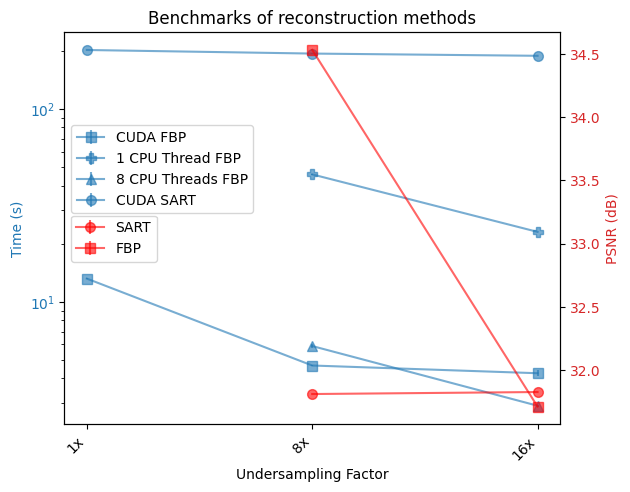

In [99]:
# I want time and quality metrics on the same plot using two y axes
import matplotlib.pyplot as plt

markersize = 7
fig, ax1 = plt.subplots()
color = 'tab:blue'
ax1.set_xlabel('Undersampling Factor')
ax1.set_ylabel('Time (s)', color=color)



# convert time_fl_plot dict to x and y values
recons = list(time_cuda_fbp.keys())
y = [time_cuda_fbp[c][0] for c in recons]
yerr = [time_cuda_fbp[c][1] for c in recons]

ax1.errorbar(recons, y, yerr=yerr, color='C0', alpha=0.6, marker='s', ms=markersize, label='CUDA FBP')
ax1.set_xticklabels(recons, rotation=45, ha='right')

# convert time_fl_plot dict to x and y values
recons = list(time_1cpu_fbp.keys())
y = [time_1cpu_fbp[c][0] for c in recons]
yerr = [time_1cpu_fbp[c][1] for c in recons]

ax1.errorbar(recons, y, yerr=yerr, color='C0', alpha=0.6, marker='P', ms=markersize, label='1 CPU Thread FBP')
ax1.set_xticklabels(recons, rotation=45, ha='right')

# convert time_fl_plot dict to x and y values
recons = list(time_8cpu_fbp.keys())
y = [time_8cpu_fbp[c][0] for c in recons]
yerr = [time_8cpu_fbp[c][1] for c in recons]

ax1.errorbar(recons, y, yerr=yerr, color='C0', alpha=0.6, marker='^', ms=markersize, label='8 CPU Threads FBP')
ax1.set_xticklabels(recons, rotation=45, ha='right')

# convert time_fl_plot dict to x and y values
recons = list(time_cuda_sart.keys())
y = [time_cuda_sart[c][0] for c in recons]
yerr = [time_cuda_sart[c][1] for c in recons]

ax1.errorbar(recons, y, yerr=yerr, color='C0', alpha=0.6, marker='o', ms=markersize, label='CUDA SART')
ax1.set_xticklabels(recons, rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor=color)

# split the y1 axis values
ax1.set_yscale('log')


plt.legend(bbox_to_anchor=(0.395, 0., 0., 0.78))

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('PSNR (dB)', color=color)  # we already handled the x-label with ax1

# convert time_fl_plot dict to x and y values
recons = list(q_sart.keys())
y = [q_sart[c][0] for c in recons]
yerr = [q_sart[c][1] for c in recons]

ax2.errorbar(recons, y, yerr=yerr, color='red', alpha=0.6, marker='o', ms=markersize, label='SART')

# convert time_fl_plot dict to x and y values
recons = list(q_cuda_fbp.keys())
y = [q_cuda_fbp[c][0] for c in recons]
yerr = [q_cuda_fbp[c][1] for c in recons]

ax2.errorbar(recons, y, yerr=yerr, color='red', alpha=0.6, marker='s', ms=markersize, label='FBP')

plt.legend(bbox_to_anchor=(0.2, 0., 0., 0.55))

ax2.tick_params(axis='y', labelcolor=color)
ax2.set_xticklabels(['1x', '8x', '16x'], rotation=45, ha='right')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Benchmarks of reconstruction methods')
plt.show()